### Avaliação Inicial dos Datasets

In [2]:
import pandas as pd

consumer = pd.read_excel('consumer_unit_data.xlsx')
print(consumer.columns)
print(consumer.shape)
print(consumer.head())
print(consumer.info())
print(consumer.isnull().sum())

power_plant = pd.read_excel('power_plant_data.xlsx')
print(power_plant.columns)
print(power_plant.shape)
print(power_plant.head())
print(power_plant.info())
print(power_plant.isnull().sum())


/home/emaia/Documents/DS/practice-dg/case1/Pesquisador-em-Ciencia-de-Dados-PD-Inteligencia-Energetica-Bolsista-10072026/.venv/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Index(['Geração Mensal Referência Month',
       'Unidade Consumidora (UC) Número de Instalação', 'Conta Consumo (kWh)',
       'Conta Saldo Acumulado (kWh)'],
      dtype='str')
(5074, 4)
  Geração Mensal Referência Month  \
0                      2025-09-01   
1                      2025-11-01   
2                      2024-11-01   
3                      2024-07-01   
4                      2024-06-01   

  Unidade Consumidora (UC) Número de Instalação  Conta Consumo (kWh)  \
0                              5.838.387.018-70                  105   
1                              2.997.780.018-21                   37   
2                              4.772.491.018-32                  135   
3                                 14.915.018-49                  556   
4                              1.111.885.018-30                    0   

   Conta Saldo Acumulado (kWh)  
0                            0  
1                         2306  
2                            0  
3                      

Primeiras linhas já indicam um problema de registro. Retirar a primeira linha já adequaria à janela temporal utilizada. Julho-2022 à Junho-2026 = 48 meses 

In [3]:
# 1. Verificar se existem registros duplicados de uma UC no mesmo mês
duplicados = consumer.duplicated(subset=['Geração Mensal Referência Month', 'Unidade Consumidora (UC) Número de Instalação']).sum()
print(f"Registros duplicados (Mesma UC no mesmo mês): {duplicados}")

# 2. Verificar se existem valores negativos (incoerentes para o negócio)
print(f"Consumos negativos: {(consumer['Conta Consumo (kWh)'] < 0).sum()}")
print(f"Saldos negativos: {(consumer['Conta Saldo Acumulado (kWh)'] < 0).sum()}")
print(f"Gerações negativas: {(power_plant['Geração Mensal SUM Energia Gerada (kWh)'] < 0).sum()}")

Registros duplicados (Mesma UC no mesmo mês): 14
Consumos negativos: 4
Saldos negativos: 0
Gerações negativas: 0


Utilizando a função criada para limpar e padronizar os datasets:

In [4]:
from src.extracao_limpeza import carregar_e_limpar

df_consumo, df_geracao, df_qualidade = carregar_e_limpar()
display(df_qualidade)

/home/emaia/Documents/DS/practice-dg/case1/Pesquisador-em-Ciencia-de-Dados-PD-Inteligencia-Energetica-Bolsista-10072026/.venv/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Etapa/Dataset,Anomalia Detectada,Volumetria,Tratamento Adotado,Justificativa
0,Geração,Registro com data nula (NaT),1,Remoção da linha (Drop),Evitar ruído na série temporal da usina.
1,Consumo,Valores de consumo (Ec) negativos,4,Substituição (Truncado para 0),Consumo físico não pode ser negativo; assume-s...
2,Consumo,Registros duplicados (Mesma UC/Mês),28,Agrupamento (Soma do Ec e Último Cr),Garantir a integridade estrutural para que a s...


- Possíveis implementações futuras para datasets mais extensos:

    - Detecção de outliers, agrupados por UC e condicionados ao histórico de consumo
    - Verificação da nomenclatura das UCs (regex, padronização)
    - Regionalização de UCs e Usinas

## EDA e Visuzalização

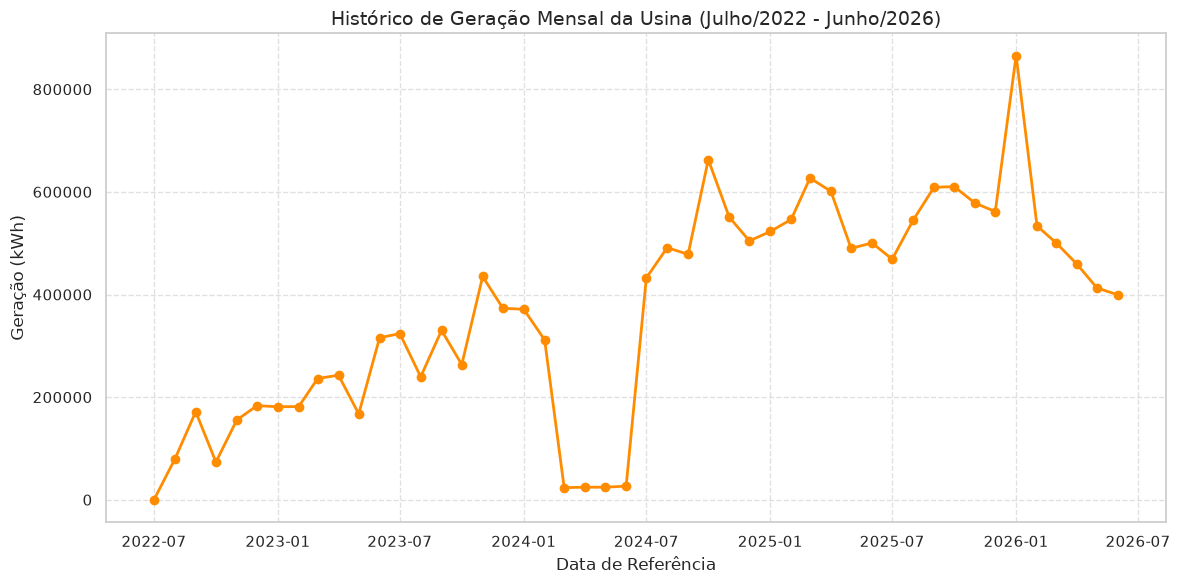

/tmp/ipykernel_229789/3445149280.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_gen_ts, x='mes', y='g', palette='Oranges')


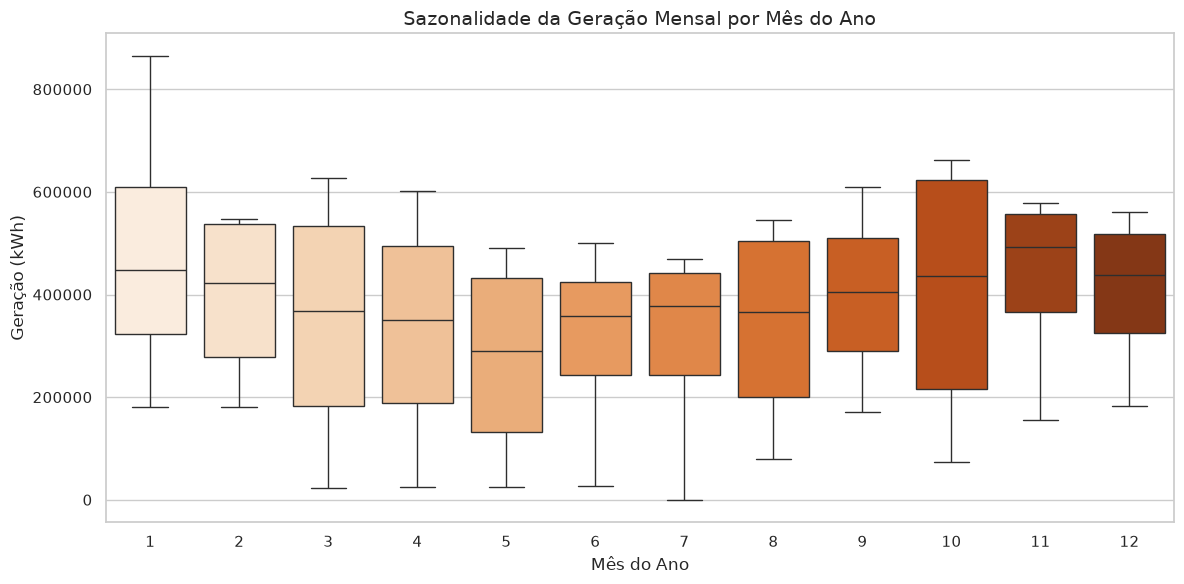

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Configuração de estilo para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Agrupar e ordenar a geração por data
df_gen_ts = df_geracao.sort_values('data_referencia')

plt.figure()
plt.plot(df_gen_ts['data_referencia'], df_gen_ts['g'], marker='o', color='darkorange', linewidth=2)
plt.title('Histórico de Geração Mensal da Usina (Julho/2022 - Junho/2026)')
plt.xlabel('Data de Referência')
plt.ylabel('Geração (kWh)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Distribuição da Geração para entender sazonalidade por mês do ano
df_gen_ts['mes'] = df_gen_ts['data_referencia'].dt.month
plt.figure()
sns.boxplot(data=df_gen_ts, x='mes', y='g', palette='Oranges')
plt.title('Sazonalidade da Geração Mensal por Mês do Ano')
plt.xlabel('Mês do Ano')
plt.ylabel('Geração (kWh)')
plt.tight_layout()
plt.show()

Podemos atestar para uma tendência de crescimento da capacidade de geração da usina durante o período, porém com uma forte queda no primeiro semestre de 2024, porém ainda não zerado, indicando possivelmente uma mudança estrutural, e não uma falha de leitura.

O agrupamento mês a mês mostra uma variabilidade sazonal esperada.

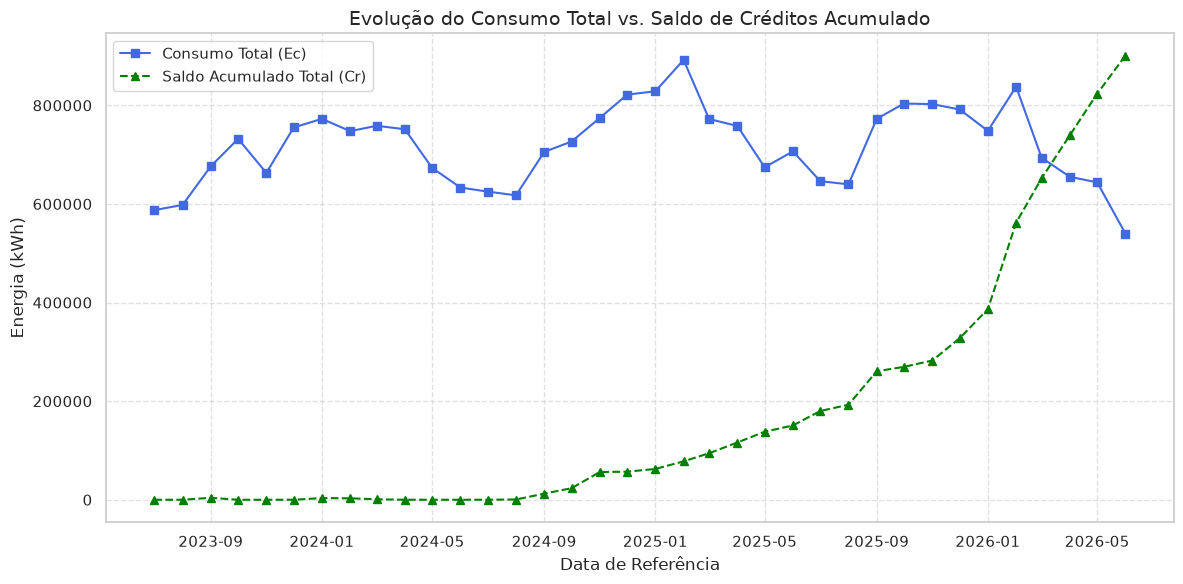

In [6]:
# Como temos muitas UCs, vamos olhar primeiro o comportamento do ecossistema inteiro somado
df_cons_agregado = df_consumo.groupby('data_referencia').agg({
    'ec': 'sum',
    'cr': 'sum'
}).reset_index()

plt.figure()
plt.plot(df_cons_agregado['data_referencia'], df_cons_agregado['ec'], marker='s', color='royalblue', label='Consumo Total (Ec)')
plt.plot(df_cons_agregado['data_referencia'], df_cons_agregado['cr'], marker='^', color='green', label='Saldo Acumulado Total (Cr)', linestyle='--')
plt.title('Evolução do Consumo Total vs. Saldo de Créditos Acumulado')
plt.xlabel('Data de Referência')
plt.ylabel('Energia (kWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

O agregado não indica nenhuma variação anômala, tanto no cumulativo, quanto na variabilidade sazonal esperada.

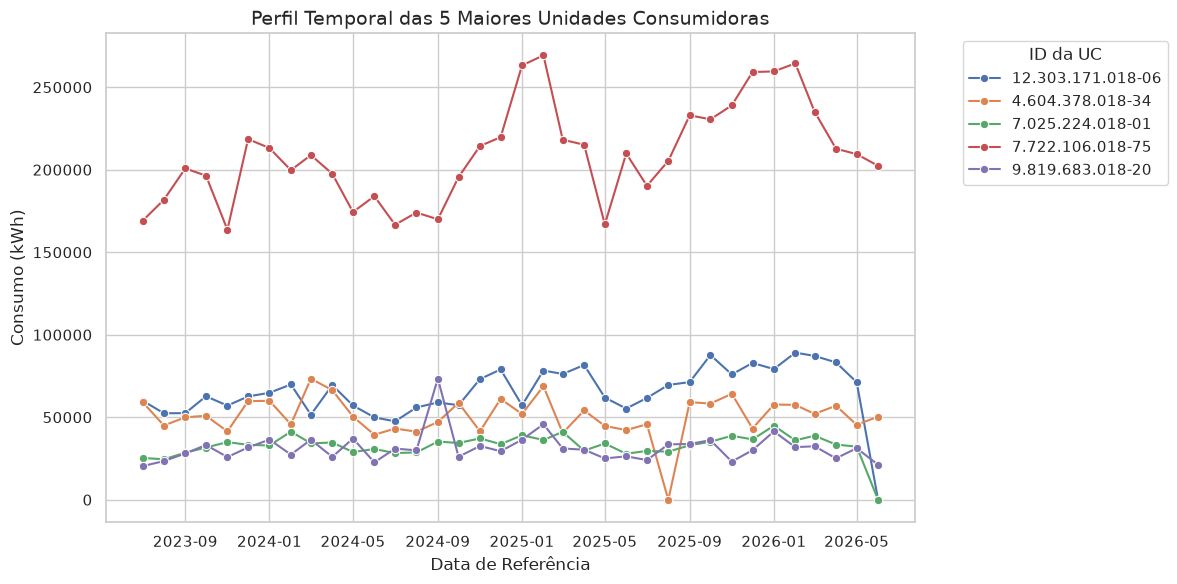

In [9]:
# Agrupar e ordenar o consumo por UC
uc_stats = df_consumo.groupby('uc')['ec'].mean().reset_index()

# Identificar as 5 maiores UCs para ver se seguem um padrão parecido
top_5_ucs = uc_stats.nlargest(5, 'ec')['uc'].tolist()
df_top5 = df_consumo[df_consumo['uc'].isin(top_5_ucs)].sort_values('data_referencia')

plt.figure()
sns.lineplot(data=df_top5, x='data_referencia', y='ec', hue='uc', marker='o')
plt.title('Perfil Temporal das 5 Maiores Unidades Consumidoras')
plt.xlabel('Data de Referência')
plt.ylabel('Consumo (kWh)')
plt.legend(title='ID da UC', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Olhando para as 5 maiores UCs podemos ver uma claramente distoante em seu consumo no período, tendo média 4 vezes maiores do que as demais maiores consumidoras. Porém sua contribuição geral não deve prejudicar a modelagem.

## Cobertura e Rateio

In [10]:
import numpy as np

def calcular_rateio_historico(df_consumo):
    """
    Aplica as regras de rateio e cobertura da Digital Grid na base limpa de consumo.
    Calcula os percentuais mês a mês para garantir integridade.
    """
    df = df_consumo.copy()
    
    # 1. Consumo Aparente (OpF = 1.0)
    df['eca'] = df['ec'] * 1.0
    
    # 2. Cobertura (Co) -> Necessidade real de novos créditos (D = 0)
    df['co'] = df['eca'] - df['cr']
    df.loc[df['co'] < 0, 'co'] = 0 # Garante que se ECA <= Cr, Co = 0
    
    # 3. Percentual de Rateio (P) calculado mês a mês (competência por competência)
    # Agrupamos por data para obter a soma de Co do mês corrente
    soma_co_mensal = df.groupby('data_referencia')['co'].transform('sum')
    
    # P = Co / Soma(Co do mês). Tratamos divisão por zero caso nenhum UC precise de crédito.
    df['p'] = np.where(soma_co_mensal > 0, df['co'] / soma_co_mensal, 0.0)
    
    return df

# Executando o cálculo
df_rateio = calcular_rateio_historico(df_consumo)

In [11]:
df_rateio["p"].sum() #Validação Geral

np.float64(36.0)

Validação de $\sum P = 1$ mês a mês.

In [12]:
# Validando se a soma de P é igual a 1 para todos os meses em que houve necessidade de crédito
validacao_mes = df_rateio.groupby('data_referencia')['p'].sum()

# Filtrando meses onde houve de fato alguma necessidade de crédito (soma > 0)
meses_com_demanda = df_rateio.groupby('data_referencia')['co'].sum() > 0
validacao_filtrada = validacao_mes[meses_com_demanda]

# Teste lógico (usando tolerance para float)
print("Validação: Todos os meses com demanda somam P = 1.0?", np.allclose(validacao_filtrada, 1.0))

Validação: Todos os meses com demanda somam P = 1.0? True


Esse resultado não garante necessariamente que o rateio está correto. Para provar que o rateio está de fato correto, é necessário realizar um teste de integridade cruzado, garantindo que o $P$ de cada UC é estritamente proporcional à sua contribuição individual de $Co$ em relação ao todo.

Para um $\sum C_0$ = 0 seria uma indeterminação matemática de divisão por 0, sendo necessário forçar o P = 0 para garantir a continuidade do sistema.
Um contorno lógico seria direcionar esse excedente gerado para um "banco" de créditos.

In [13]:
import duckdb

# Conecta a um banco em memória e registra o DataFrame limpo da Q0
con = duckdb.connect(database=':memory:')
con.register('df_consumo_limpo', df_consumo)

# Query única do DF Q0
query = """
WITH calculo_cobertura AS (
    SELECT 
        uc,
        (ec * 1.0) AS eca,
        cr,
        CASE 
            WHEN (ec * 1.0) > cr THEN (ec * 1.0) - cr 
            ELSE 0.0 
        END AS co
    FROM df_consumo_limpo
    -- Ajustado para o último mês real do histórico (ou mude para a data que aparecer no teste acima)
    WHERE data_referencia = '2026-06-01' 
)
SELECT 
    uc,
    eca,
    cr,
    co,
    CASE 
        WHEN SUM(co) OVER() > 0 THEN co / SUM(co) OVER()
        ELSE 0.0
    END AS p
FROM calculo_cobertura;
"""

df_sql_resultado = con.execute(query).df()
print(df_sql_resultado.head())

                 uc     eca  cr      co         p
0  1.111.885.018-30  2323.0   0  2323.0  0.004354
1  1.114.480.018-84   305.0   0   305.0  0.000572
2  1.128.584.018-23  1714.0   0  1714.0  0.003212
3  1.197.958.018-54   300.0   0   300.0  0.000562
4  1.263.234.018-48  5452.0   0  5452.0  0.010218


In [14]:
# 1. Filtro
df_q1_junho = df_rateio[df_rateio['data_referencia'] == '2026-06-01'].sort_values('uc').reset_index(drop=True)

# 2. Ordenação
df_q2_sql = df_sql_resultado.sort_values('uc').reset_index(drop=True)

# 3. Comparação
co_batem = np.allclose(df_q1_junho['co'], df_q2_sql['co'])
p_batem = np.allclose(df_q1_junho['p'], df_q2_sql['p'])

print(f"{co_batem}")
print(f"{p_batem}")

True
True


## Previsão de Consumo

1. Definição dos Modelos para o Consumo: 
    - Baseline (Média Móvel Histórica): Para cada UC, a previsão para Julho/2026 será a média do consumo dela nos últimos 3 ou 12 meses.
    - Modelo Avançado (Random Forest): Criamos uma única base agregada onde usamos o consumo dos meses anteriores ($t-1, t-2, t-12$) como variáveis explicativas (features) para prever o mês atual.

In [15]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Previsão consumo

df_co = df_rateio.sort_values(['uc', 'data_referencia']).reset_index(drop=True)

# 1. Definição de Features de Lag
df_co['lag_1'] = df_co.groupby('uc')['ec'].shift(1)
df_co['lag_2'] = df_co.groupby('uc')['ec'].shift(2)
df_co['lag_12'] = df_co.groupby('uc')['ec'].shift(12)

# Baseline para validação: Média móvel dos últimos 3 meses (visto de t-1)
df_co['baseline'] = df_co.groupby('uc')['ec'].transform(lambda x: x.rolling(3, min_periods=1).mean().shift(1))

df_model_co = df_co.dropna(subset=['lag_1', 'lag_2', 'lag_12']).copy()

# Passo 1: Divisão para VALIDAÇÃO (Treinar até Maio, Validar em Junho)
train_val_co = df_model_co[df_model_co['data_referencia'] < '2026-06-01']
val_co = df_model_co[df_model_co['data_referencia'] == '2026-06-01']

features_co = ['lag_1', 'lag_2', 'lag_12']

rf_co = RandomForestRegressor(n_estimators=100, random_state=1, max_depth=6)
rf_co.fit(train_val_co[features_co], train_val_co['ec'])

# Avaliação em Junho/2026
preds_val_co = rf_co.predict(val_co[features_co])
mae_base_co = mean_absolute_error(val_co['ec'], val_co['baseline'])
mae_rf_co = mean_absolute_error(val_co['ec'], preds_val_co)

print(f"[Validação Junho] MAE Baseline: {mae_base_co:.2f} | MAE Random Forest: {mae_rf_co:.2f}")

# Passo 2: RETREINO INCLUINDO JUNHO PARA PREVER JULHO
# Todos dados disponíveis (incluindo junho) para ajustar o modelo final
rf_co_final = RandomForestRegressor(n_estimators=100, random_state=1, max_depth=6)
rf_co_final.fit(df_model_co[features_co], df_model_co['ec'])

# Criando a linha de Julho/2026 para cada UC para receber a previsão
ultimos_dados_co = df_model_co[df_model_co['data_referencia'] == '2026-06-01'].copy()
julho_co = ultimos_dados_co.copy()
julho_co['data_referencia'] = pd.to_datetime('2026-07-01')

# Mudança de lags: o lag_1 de julho se torna o 'ec' de junho, etc.
julho_co['lag_2'] = julho_co['lag_1']
julho_co['lag_1'] = julho_co['ec']
# Para o lag_12 (Julho/2025), precisamos buscar no histórico real
lag_12_julho = df_model_co[df_model_co['data_referencia'] == '2025-07-01'].set_index('uc')['ec']
julho_co['lag_12'] = julho_co['uc'].map(lag_12_julho)

# Predict de Julho/2026
julho_co['prev_ec'] = rf_co_final.predict(julho_co[features_co])

[Validação Junho] MAE Baseline: 1195.39 | MAE Random Forest: 1431.62


Na validação de Junho/2026 para o consumo, o Baseline de média móvel superou o modelo de Random Forest. Isso demonstra que para a escala e variabilidade das UCs deste dataset, a inércia do consumo recente é um preditor mais estável. Portanto, seguindo o rigor metodológico, utilizaremos o **Baseline (Média Móvel)** para gerar as projeções de consumo de Julho/2026 que alimentarão a Q4.

Possivelmente isso ocorre porque o modelo de Random Forest tem dificuldades em captar a heterogeneidade das UCs, tendendo a se "agarrar" as médias globais.

Previsão da Geração:

In [16]:
df_gen_model = df_geracao.sort_values('data_referencia').reset_index(drop=True)
df_gen_model['mes'] = df_gen_model['data_referencia'].dt.month
df_gen_model['lag_1'] = df_gen_model['g'].shift(1)
df_gen_model['lag_12'] = df_gen_model['g'].shift(12)
df_gen_model['baseline_gen'] = df_gen_model['g'].shift(12) # Sazonalidade pura do ano anterior

df_model_gen = df_gen_model.dropna().copy()

# Passo 1: Divisão para VALIDAÇÃO (Treinar até Maio, Validar em Junho)
train_val_gen = df_model_gen[df_model_gen['data_referencia'] < '2026-06-01']
val_gen = df_model_gen[df_model_gen['data_referencia'] == '2026-06-01']

features_gen = ['mes', 'lag_1', 'lag_12']

rf_gen = RandomForestRegressor(n_estimators=50, random_state=1)
rf_gen.fit(train_val_gen[features_gen], train_val_gen['g'])

# Avaliação em Junho/2026
preds_val_gen = rf_gen.predict(val_gen[features_gen])
mae_base_gen = mean_absolute_error(val_gen['g'], val_gen['baseline_gen'])
mae_rf_gen = mean_absolute_error(val_gen['g'], preds_val_gen)

print(f"[Validação Junho] MAE Baseline: {mae_base_gen:.2f} | MAE Random Forest: {mae_rf_gen:.2f}")

# Passo 2: RETREINO INCLUINDO JUNHO PARA PREVER JULHO
rf_gen_final = RandomForestRegressor(n_estimators=50, random_state=1)
rf_gen_final.fit(df_model_gen[features_gen], df_model_gen['g'])

# Criando a linha de Julho/2026 para a Usina
ultima_linha_gen = df_model_gen[df_model_gen['data_referencia'] == '2026-06-01'].iloc[0]
julho_gen_features = pd.DataFrame([{
    'mes': 7,
    'lag_1': ultima_linha_gen['g'], # Geração de junho vira lag_1
    'lag_12': df_model_gen[df_model_gen['data_referencia'] == '2025-07-01']['g'].values[0] # Julho/2025 vira lag_12
}])

prev_julho_geracao = rf_gen_final.predict(julho_gen_features)[0]
print(f"PREVISÃO FINAL DE GERAÇÃO PARA JULHO/2026: {prev_julho_geracao:.2f} kWh")

[Validação Junho] MAE Baseline: 101164.00 | MAE Random Forest: 29643.18
PREVISÃO FINAL DE GERAÇÃO PARA JULHO/2026: 415570.20 kWh


Aqui podemos utilizar o mesmo raciocínio para o resultado do modelo para o consumo. Se tratando de apenas uma unidade geradora o ganho em precisão é muito grande, favorecendo o modelo de Random Forest.

Cobertura de carteira para Julho/2026:

In [ ]:
# 1. Saldo acumulado final de junho/2026
df_junho = df_rateio[df_rateio['data_referencia'] == '2026-06-01']
saldo_atual = df_junho.set_index('uc')['cr']

# 2. estrutura de Julho/2026
df_q4 = pd.DataFrame({'uc': df_rateio['uc'].unique()})

# 3. Filtro seguro convertendo para string para evitar incompatibilidade de tipos de data
df_rateio['data_str'] = df_rateio['data_referencia'].dt.strftime('%Y-%m-%d')
df_ultimos_3 = df_rateio[df_rateio['data_str'].isin(['2026-04-01', '2026-05-01', '2026-06-01'])]

# Calcula a média móvel (ECA previsto)
media_movel_3m = df_ultimos_3.groupby('uc')['ec'].mean()


df_q4['eca_prev'] = df_q4['uc'].map(media_movel_3m).fillna(0)
df_q4['cr_atual'] = df_q4['uc'].map(saldo_atual).fillna(0)

# 4. Cálculo da Cobertura Prevista
df_q4['co_prev'] = df_q4['eca_prev'] - df_q4['cr_atual']
df_q4.loc[df_q4['co_prev'] < 0, 'co_prev'] = 0.0

# 5. Novo Rateio Otimizado (P)
soma_co_prev = df_q4['co_prev'].sum()
if soma_co_prev > 0:
    df_q4['p_otimizado'] = df_q4['co_prev'] / soma_co_prev
else:
    df_q4['p_otimizado'] = 0.0

# 6. Distribuição da Geração Prevista (Q3: 415570.20 kWh)
g_previsto = 415570.20
df_q4['injecao_kwh'] = df_q4['p_otimizado'] * g_previsto

# Print para conferência interna dos números reais
print(f"Soma total da necessidade de cobertura (Soma Co_prev): {soma_co_prev:.2f} kWh")
print(df_q4[['uc', 'eca_prev', 'cr_atual', 'co_prev', 'p_otimizado', 'injecao_kwh']].head())

Soma total da necessidade de cobertura (Soma Co_prev): 607603.67 kWh
                 uc     eca_prev  cr_atual      co_prev  p_otimizado  \
0  1.111.885.018-30  2566.333333       0.0  2566.333333     0.004224   
1  1.114.480.018-84   315.333333       0.0   315.333333     0.000519   
2  1.128.584.018-23  1991.333333       0.0  1991.333333     0.003277   
3  1.263.234.018-48  4850.666667       0.0  4850.666667     0.007983   
4  1.760.680.018-10   573.333333       0.0   573.333333     0.000944   

   injecao_kwh  
0  1755.242299  
1   215.672063  
2  1361.971359  
3  3317.610850  
4   392.131024  


- Balanço Energético de Julho/2026:
    - Geração Prevista da Usina (Random Forest): 415.570,20 kWh
    - Necessidade de Cobertura da Carteira ($\sum Co_{prev}$): 607.603,67 kWh

- Não haverá cobertura, assim as possibilidade são:
    - Utilizar um saldo no banco créditos, se disponível (como sugerida criação no Q2).  
    - Verificar o excedente de demais Usinas Geradoras.
    - Se nem uma das duas alternativas for possível, avisar as UCs da necessidade de complementação e cobertura com a distribuidora tradicional.


## Rebalanceamento Dinâmico